# Deep Learning-Based Image Denoising with Noise2Void 2

## Introduction

Welcome to the 3<sup>st</sup> notebook in the Bioimage analysis in Python course! This notebook introduces you to modern deep learning approaches for image denoising using the Noise2Void 2 (N2V2) algorithm.

## Why Denoising Matters

Noise is an inevitable component of all microscopy images, arising from:
- **Photon shot noise**: Fundamental limit of light detection
- **Camera readout noise**: Electronic noise from the detector
- **Environmental factors**: Vibrations, temperature fluctuations
- ...

Traditional denoising methods often require clean reference images, which are rarely available in biological imaging. Noise2Void revolutionized this field by enabling **self-supervised denoising** - training models using only noisy images.

## Learning Objectives

By completing this notebook, you will:

1. **Understand** the principles of self-supervised denoising with Noise2Void
2. **Install and configure** the CAREamics framework for deep learning denoising
3. **Train** a custom N2V2 model on scanning electron microscopy (SEM) data
4. **Evaluate** model performance through visual and quantitative assessment
5. **Apply** the trained model to denoise new images
6. **Export** models for sharing and future use

## Noise2Void 2: Key Concepts

### The Innovation
- **Self-supervised**: No clean images required for training
- **Blind spot network**: Model cannot see the pixel it's trying to predict
- **Denoising**: Based on neighboring pixels, it tries to predict the pixel intensity. Since will not be able to predict the random noise present in the image, it will converge to predicting the underlying signal. It will effectively learn to denoise our images.

### When to Use N2V2
- ✅ High noise levels affecting analysis
- ✅ No clean reference images available
- ✅ Repetitive imaging conditions (same microscope setup)
- ✅ Sufficient training data (hundreds of images)

### Limitations
- May remove fine structural details
- Requires retraining for different imaging conditions
- Computationally intensive training process

## Course Workflow

This notebook follows a typical deep learning pipeline:

1. **Setup**: Install dependencies and configure environment
2. **Data Loading**: Download and examine SEM training data
3. **Model Configuration**: Set up N2V2 parameters
4. **Training**: Train the denoising model with validation
5. **Prediction**: Apply the trained model to test images
6. **Evaluation**: Assess denoising quality
7. **Export**: Package model for future use

## Expected Outcomes

After completing this notebook, you will have:
- A trained N2V2 model for SEM image denoising
- Understanding of deep learning training principles
- Skills to adapt the approach to your own data
- A portable model that can be shared and reused

**Let's start building your denoising expertise!**

## Setup

First, we will connect to the correct runtime environment. Since we we are going to use deep learning, we would really benefit from having a GPU. Therefore, we will connect to a GPU runtime environment.

Select a Python with GPU runtime

- Click on Connect > Change the runtime

![Change runtime](https://drive.google.com/uc?export=view&id=1Rgloj9hRS-FZD9dQFN2IZXwSWs_rd8Rs)

- Select Runtime Python and with a GPU

![Select GPU runtime](https://drive.google.com/uc?export=view&id=13fBkTvz3gmtySh9QQWBDNT_msqD0xOiX)


Check if we have the GPU available

In [ ]:
import torch
torch.cuda.is_available()

Next, we install the necessary libraries.

In [ ]:
!pip uninstall torch
!pip install torch torchvision --index-url https://download.pytorch.org/whl/cu118

In [ ]:
!pip install "careamics[examples]"

In [ ]:
# Check if we have the GPU available
import torch
torch.cuda.is_available()

Now, we import the necessary libraries.

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import tifffile
from careamics import CAREamist
from careamics.config import create_n2v_configuration
from careamics_portfolio import PortfolioManager
from PIL import Image

We will use example data from the CAREamics framework. To obtain the data, we will use the `careamics_portfolio` library. We will save the data in the `./data` folder of the virtual environment.

In [ ]:
# instantiate data portfolio manage
portfolio = PortfolioManager()

# and download the data
root_path = Path("./data")
files = portfolio.denoising.N2V_SEM.download(root_path)

Now, we will define a training and a validation image. We will train our denoising model on image 0, and validate it on image 1. Let's see how these images look like.

Text(0.5, 1.0, 'Validation Image')

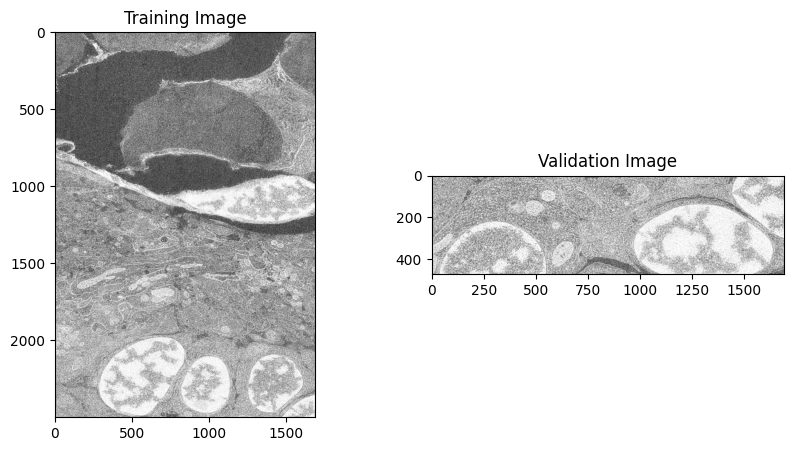

In [ ]:
# Load training and validation image and show them side by side
train_image = tifffile.imread(files[0])
val_image = tifffile.imread(files[1])

fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(train_image, cmap="gray")
ax[0].set_title("Training Image")
ax[1].imshow(val_image, cmap="gray")
ax[1].set_title("Validation Image")

Next, we will define the model parameters. CAREamics provides a convenient way to define our configuration using the `create_n2v_configuration` function.

Let's zoom in on some of the parameters:
- `patch_size`: size of image patches that we will use to train the model. This will split up our training image(s) into smaller patches. This way, we can train the model efficiently without overflowing the GPU memory. We will use 64x64 patches.
- `batch_size`: number of patches that we will use to train the model in each iteration. We will use 32 patches. The larger the batch size, the quicker our model will converge. However, a larger batch size also means a larger GPU memory usage.
- `num_epochs`: number of epochs that we will train the model for. This is the number of times that we will iterate over the entire training dataset. We will train for 30 epochs. More epochs gives the model more time to learn. Besides a longer training time, it also increases the risk of overfitting.
- `axes` : type of patch used to train the model. Could be `XY` for individual 2D patches, `SYX` for stack of 2D patches, `ZYX` for 3D patches. If you have a 3D pacthes, you need to have a path_size for the 3 values (e.g., `patch_size=(12,64,64)` for Z,Y,X).

If we print the configuration, we can see the full list of parameters. Many of these parameters are set to default values that are generally good choices, so we don't need to specify them for now.

In [ ]:
config = create_n2v_configuration(
    experiment_name="p2n2025_n2v_sem",
    data_type="array",
    axes="YX",
    patch_size=(64, 64),
    batch_size=32,
    num_epochs=30,
    use_n2v2=True,
)

print(config)

With the configuration defined, we can now create the model. We will use the `CAREamics` class to create the model. Depending on the configuration, this will create a model with a different architecture or hyperparameters. We will use the configuration that we defined earlier.

Once created, we can train the model using its `train` method. This method will take the training and validation images as input. All other things going on behind the scenes are taken care of by the `CAREamics` class.

In [ ]:
# instantiate a CAREamist
careamist = CAREamist(source=config, , work_dir='./')

# train
careamist.train(
    train_source=train_image,
    val_source=val_image,
)

The model will be saved in `$work_dir/checkpoints/p2n2025_n2v_sem/p2n2025_n2v_sem_last.ckpt`

Now that our model is trained, let's use it to denoise our images. We will first look at the denoising results on the training image.

In [ ]:
prediction = careamist.predict(source=train_image, tile_size=(256, 256))

# Show the full image and crops
x_start, x_end = 600, 850
y_start, y_end = 200, 450

fig, ax = plt.subplots(2, 2, figsize=(10, 10))
ax[0, 0].imshow(train_image, cmap="gray")
ax[0, 1].imshow(prediction[0].squeeze(), cmap="gray")
ax[1, 0].imshow(train_image[y_start:y_end, x_start:x_end], cmap="gray")
ax[1, 1].imshow(prediction[0].squeeze()[y_start:y_end, x_start:x_end], cmap="gray")

Load a model

By default, `train` from `CAREamist` save the checkpoint model into a subfolder `./checkpoints/` of the working directory. The last checkpoing will be named `last.ckpt`

In [ ]:
# Load manually a model for a prediction
careamist = CAREamist(source="checkpoints/mon_modele.ckpt")

## References:
- [Careamics](https://careamics.github.io/latest/) 🔗
- [Careamics Napari Plugins](https://careamics.github.io/latest/content/guides/napari_plugin/) 🔗